# ERP Cleanup — hybrid parsing pipeline: analysis notebook

Phase 4 of the ERP Output Cleanup case study (see `design/design.md` §§1 and
4). This notebook reads the Phase 3 run outputs — `data/runs/evaluation.json`
and `data/runs/parse_agent_log.json` — and reproduces every table and figure
below directly from those files, computed at run time. Nothing here is
retyped from `data/runs/report.md`; the report and this notebook are two
views of the same run.

**The corpus is synthetic.** Jalavakoski Konepaja Oy does not exist. Its
SAP-style spool exports are an engineered corpus with a known answer key, so
the results below are *marked, not asserted* — every field of every document
was scored against a ground-truth record that never entered the parsing
path. That is what makes the numbers checkable rather than claimed.

**What this demonstrates.** A stream of 240 ERP documents is routed through a
hybrid pipeline: an LLM parses each document until an overseer has seen
enough consistent examples of a transaction type to generate a deterministic
parser, after which routine documents of that type parse in milliseconds at
zero marginal cost. The design's pre-registered outcome table
(`design/design.md` §4) is scored below against what actually happened,
including where the system deviated from the design, and where one planted
failure got past every automated check.

Cost figures throughout are **estimates** (method B — Claude Code subagents,
not metered API calls); accuracy figures are **exact** against the answer
key. Both distinctions are re-stated at the point they matter.

## Setup

Imports, path resolution, and the constants (palette, pricing) used
throughout. The path helper walks upward from the current working directory
until it finds `data/runs/`, so the notebook runs the same whether launched
from `notebooks/` (the normal case) or from the project root.

In [1]:
import json
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

pd.set_option("display.max_colwidth", 120)


def find_project_root(start: Path) -> Path:
    """Walk upward from *start* until a directory containing 'data/runs' is found.

    Makes the notebook robust to being run from notebooks/ (the normal case)
    or from the project root, without hardcoding either location.
    """
    for candidate in [start, *start.parents]:
        if (candidate / "data" / "runs").is_dir():
            return candidate
    raise FileNotFoundError(
        f"Could not find a 'data/runs' directory above {start}. "
        "Run this notebook from the case study's notebooks/ folder or its project root."
    )


PROJECT_ROOT = find_project_root(Path.cwd())
DATA_RUNS_DIR = PROJECT_ROOT / "data" / "runs"
EVALUATION_PATH = DATA_RUNS_DIR / "evaluation.json"
PARSE_LOG_PATH = DATA_RUNS_DIR / "parse_agent_log.json"

print(f"Project root resolved to : {PROJECT_ROOT}")
print(f"Reading evaluation data  : {EVALUATION_PATH}")
print(f"Reading parse-agent log  : {PARSE_LOG_PATH}")

Project root resolved to : C:\Users\luigi\Dropbox\Archivio famiglia\Hapax\Case Studies\02 ERP Cleanup
Reading evaluation data  : C:\Users\luigi\Dropbox\Archivio famiglia\Hapax\Case Studies\02 ERP Cleanup\data\runs\evaluation.json
Reading parse-agent log  : C:\Users\luigi\Dropbox\Archivio famiglia\Hapax\Case Studies\02 ERP Cleanup\data\runs\parse_agent_log.json


In [2]:
def load_json(path: Path) -> dict:
    """Load a JSON file, failing with an informative message rather than a bare crash."""
    if not path.exists():
        raise FileNotFoundError(
            f"Expected input file not found: {path}\n"
            "This notebook only reads from data/runs/ — check the case study folder layout."
        )
    try:
        with path.open("r", encoding="utf-8") as f:
            return json.load(f)
    except json.JSONDecodeError as exc:
        raise ValueError(f"Could not parse {path} as JSON: {exc}") from exc


evaluation = load_json(EVALUATION_PATH)
parse_agent_log = load_json(PARSE_LOG_PATH)

print(f"evaluation.json      : {len(evaluation['docs'])} documents, "
      f"{len(evaluation['activation_events'])} parser-activation events")
print(f"parse_agent_log.json : method = {parse_agent_log['method']}")

evaluation.json      : 240 documents, 5 parser-activation events
parse_agent_log.json : method = B - Claude Code subagents (claude-sonnet-5 class), per DECISIONS.md 'Cost-method correction'


In [3]:
# Colour palette and shared config for this notebook's figures — fixed once
# here, not chosen chart-by-chart.
COLOR_COUNTERFACTUAL = "#A03C31"   # All-LLM counterfactual
COLOR_HYBRID = "#3D538F"           # Hybrid pipeline / deterministic path
COLOR_ACTIVATION = "#B68A2C"       # Parser-activation events / LLM fallback
COLOR_SILENT_ERROR = "#1A1410"     # The single S-class silent error
COLOR_MUTED_TICK = "#665E58"       # Muted tick-label grey

PATH_COLORS = {
    "deterministic": COLOR_HYBRID,
    "llm_discovery": COLOR_COUNTERFACTUAL,
    "llm_fallback": COLOR_ACTIVATION,
}

# Published per-token prices, read from parse_agent_log.json — not retyped.
PRICING = parse_agent_log["pricing_reference"]


def cost_band_usd(tokens, price_in_per_mtok, price_out_per_mtok, input_share=0.85, output_share=0.15):
    """
    Estimate a USD cost band from an undifferentiated subagent token count.

    subagent_tokens mix input and output with no split recorded, so:
      floor   = every token billed as input  (cheapest published rate)
      ceiling = every token billed as output (priciest published rate)
      central = an 85/15 input/output split, per report.md's method note
                (agent sessions are input-heavy: reading documents, scripts,
                self-verification)

    Returns (floor, central, ceiling) in USD.
    """
    floor = tokens * price_in_per_mtok / 1e6
    ceiling = tokens * price_out_per_mtok / 1e6
    central = tokens * (input_share * price_in_per_mtok + output_share * price_out_per_mtok) / 1e6
    return floor, central, ceiling


print(f"Pricing reference: {PRICING['source']}")
print(f"  ${PRICING['usd_per_mtok_input']:.2f} / MTok input, "
      f"${PRICING['usd_per_mtok_output']:.2f} / MTok output "
      f"({PRICING['model_class']})")

Pricing reference: Anthropic published list prices, checked 2026-07-03 via the claude-api reference skill
  $3.00 / MTok input, $15.00 / MTok output (Claude Sonnet tier (claude-sonnet-5))


## Corpus overview

240 synthetic documents across five SAP-style transaction types (FBL3N,
FBL1N, ME2M, VA05, MB52), spanning twelve month-end batches (January to
December 2025). Every document carries a pre-registered class — R (routine),
V (variant), F (fail-and-recover), or S (silent error) — fixed by the design
before any parsing ran (`design/design.md` §4). The crosstab below is read
directly from `evaluation.json`'s `docs[]`.

In [4]:
docs_df = pd.DataFrame(evaluation["docs"]).sort_values("idx").reset_index(drop=True)

print(f"Corpus: {len(docs_df)} documents, {docs_df['type'].nunique()} transaction types, "
      f"{docs_df['month'].nunique()} month-end batches "
      f"({docs_df['month'].min()} to {docs_df['month'].max()}).")

type_class_counts = pd.crosstab(docs_df["type"], docs_df["class"], margins=True, margins_name="Total")
type_class_counts

Corpus: 240 documents, 5 transaction types, 12 month-end batches (2025-01 to 2025-12).


class,F,R,S,V,Total
type,,,,,
FBL1N,5,43,0,0,48
FBL3N,0,45,0,3,48
MB52,0,48,0,0,48
ME2M,5,42,1,0,48
VA05,5,40,0,3,48
Total,15,218,1,6,240


## The stream replay

Documents are replayed in stream (date) order through the router: a
deterministic parser first if one exists for the type, an LLM call
otherwise. Two LLM cases are distinguished: *discovery* documents (the
first-of-type documents that fund a type's future deterministic parser) and
*fallback* documents (a deterministic parse that failed validation and got a
second pass from the LLM).

The design pre-registered a deterministic share of **≈75%** (179/240,
`design.md` §4) before any document was parsed. The computed share below is
checked live against `evaluation.json`'s own summary, rather than retyped.

In [5]:
path_counts_df = (
    docs_df["path"]
    .value_counts()
    .reindex(["llm_discovery", "deterministic", "llm_fallback"])
    .rename("documents")
    .to_frame()
)
path_counts_df["share_of_stream_pct"] = (100 * path_counts_df["documents"] / len(docs_df)).round(2)

deterministic_share = docs_df["path"].eq("deterministic").mean()

# Sanity check: our own recomputation must agree with evaluation.json's summary.
summary_share = evaluation["summary"]["deterministic_share"]
assert abs(deterministic_share - summary_share) < 0.001, (
    f"Computed deterministic share ({deterministic_share:.4f}) does not match "
    f"evaluation.json summary.deterministic_share ({summary_share:.4f})"
)

print(f"Deterministic share of the {len(docs_df)}-document stream: {deterministic_share:.2%} "
      f"({docs_df['path'].eq('deterministic').sum()} of {len(docs_df)} documents)")
print(f"Pre-registered design target: ≈75% (179/240) — gap: "
      f"{100 * deterministic_share - 75:.1f} percentage points")

path_counts_df

Deterministic share of the 240-document stream: 76.67% (184 of 240 documents)
Pre-registered design target: ≈75% (179/240) — gap: 1.7 percentage points


,documents,share_of_stream_pct
path,,
llm_discovery,40,16.67
deterministic,184,76.67
llm_fallback,16,6.67


## Accuracy per path

Field-level accuracy, scored against the answer key, split by which path
produced the result. Two things are worth separating: how often the LLM
path was wrong, and how often the deterministic path was wrong — and, within
the deterministic path, how much of that error is one planted document
rather than a systemic problem.

In [6]:
accuracy_summary = evaluation["summary"]["accuracy"]
accuracy_df = pd.DataFrame(accuracy_summary).T
accuracy_df["field_accuracy_pct"] = (accuracy_df["field_accuracy"] * 100).round(4)
accuracy_df = accuracy_df[["docs", "fields", "wrong", "field_accuracy_pct"]]
accuracy_df

,docs,fields,wrong,field_accuracy_pct
llm,56.0,34470.0,13.0,99.9623
deterministic,184.0,137726.0,66.0,99.9521


### The 13 LLM-path mismatches

Every wrong field on the LLM path, expanded from `docs[].mismatches`. All 13
share the same root cause (`report.md`, "LLM-path findings"): the
fallback-wave prompts dropped the discovery prompts' qualifier for the
organisation-code field ("the *number* after
Einkaufsorganisation:/Verkaufsorganisation:"), so agents captured the whole
line instead of the code.

In [7]:
MISMATCH_PATTERN = re.compile(r"^(?P<field>.+?): got (?P<got>.*) want (?P<want>.*)$")


def parse_mismatches(doc_row: pd.Series) -> list[dict]:
    """Expand one document's mismatches[] strings into one row per field mismatch."""
    parsed = []
    for raw in doc_row["mismatches"]:
        match = MISMATCH_PATTERN.match(raw)
        if match is None:
            raise ValueError(f"Mismatch string did not match the expected pattern: {raw!r}")
        parsed.append({
            "doc_id": doc_row["doc_id"],
            "path": doc_row["path"],
            "field": match.group("field"),
            "got": match.group("got"),
            "want": match.group("want"),
        })
    return parsed


llm_path_docs = docs_df[docs_df["path"].isin(["llm_discovery", "llm_fallback"])]
llm_mismatch_rows = [row for _, doc_row in llm_path_docs.iterrows() for row in parse_mismatches(doc_row)]
llm_mismatches_df = pd.DataFrame(llm_mismatch_rows)

print(f"LLM-path field mismatches: {len(llm_mismatches_df)} "
      f"(across {llm_mismatches_df['doc_id'].nunique()} documents)")
llm_mismatches_df

LLM-path field mismatches: 13 (across 13 documents)


,doc_id,path,field,got,want
0,2025-08_VA05_04,llm_fallback,header.sales_org,'1000 Jalavakoski Konepaja Oy','1000'
1,2025-09_ME2M_04,llm_fallback,header.purch_org,'1000 Jalavakoski Konepaja Oy','1000'
2,2025-09_VA05_03,llm_fallback,header.sales_org,'1000 Jalavakoski Konepaja Oy','1000'
3,2025-09_VA05_04,llm_fallback,header.sales_org,'1000 Jalavakoski Konepaja Oy','1000'
4,2025-10_ME2M_04,llm_fallback,header.purch_org,'1000 Jalavakoski Konepaja Oy','1000'
5,2025-10_VA05_03,llm_fallback,header.sales_org,'1000 Jalavakoski Konepaja Oy','1000'
6,2025-10_VA05_04,llm_fallback,header.sales_org,'1000 Jalavakoski Konepaja Oy','1000'
7,2025-11_ME2M_03,llm_fallback,header.purch_org,'1000 Jalavakoski Konepaja Oy','1000'
8,2025-11_ME2M_04,llm_fallback,header.purch_org,'1000 Jalavakoski Konepaja Oy','1000'
9,2025-11_VA05_03,llm_fallback,header.sales_org,'1000 Jalavakoski Konepaja Oy','1000'


### The planted silent error: with and without the S-class document

One ME2M document (class S) was designed to parse cleanly, pass every
automated check, and be silently wrong — a swapped `net_price` /
`still_to_deliver_value` pair, upstream corruption that no schema, totals,
or master-data check catches (`design.md` §4). It accounts for every wrong
field the deterministic path produced.

In [8]:
deterministic_docs = docs_df[docs_df["path"] == "deterministic"]
s_class_docs = deterministic_docs[deterministic_docs["class"] == "S"]
deterministic_excl_s = deterministic_docs[deterministic_docs["class"] != "S"]


def field_accuracy(subset: pd.DataFrame) -> tuple[int, int, float]:
    total_fields = int(subset["fields"].sum())
    total_wrong = int(subset["wrong_fields"].sum())
    return total_fields, total_wrong, (total_fields - total_wrong) / total_fields


fields_incl, wrong_incl, acc_incl = field_accuracy(deterministic_docs)
fields_excl, wrong_excl, acc_excl = field_accuracy(deterministic_excl_s)

s_split_df = pd.DataFrame([
    {
        "scope": "Deterministic path, including the planted S-class document",
        "docs": len(deterministic_docs), "fields": fields_incl, "wrong": wrong_incl,
        "field_accuracy_pct": round(100 * acc_incl, 4),
    },
    {
        "scope": "Deterministic path, excluding the planted S-class document",
        "docs": len(deterministic_excl_s), "fields": fields_excl, "wrong": wrong_excl,
        "field_accuracy_pct": round(100 * acc_excl, 4),
    },
]).set_index("scope")

assert len(s_class_docs) == 1, f"Expected exactly one S-class document, found {len(s_class_docs)}"
print(f"S-class document: {s_class_docs.iloc[0]['doc_id']} "
      f"({int(s_class_docs.iloc[0]['wrong_fields'])} wrong fields of {int(s_class_docs.iloc[0]['fields'])})")
s_split_df

S-class document: 2025-11_ME2M_02 (66 wrong fields of 513)


,docs,fields,wrong,field_accuracy_pct
scope,,,,
"Deterministic path, including the planted S-class document",184,137726,66,99.9521
"Deterministic path, excluding the planted S-class document",183,137213,0,100.0000


## The designed-outcome scorecard

Every document's pre-registered class (`design.md` §4) scored against what
actually happened, read from `evaluation.json`'s
`summary.designed_outcome_scorecard`. R, V, and S landed as designed; F did
not — five of the fifteen fail-and-recover documents were meant to break
their generated parser and route back to the LLM, but the generated FBL1N
parser handled them correctly instead. The deviation is reported below
verbatim, not smoothed over: the pre-registration stayed frozen, so the gap
is checkable rather than a claim.

In [9]:
scorecard_raw = evaluation["summary"]["designed_outcome_scorecard"]
scorecard_rows = []
for cls, info in scorecard_raw.items():
    row = {"class": cls, "designed": info["designed"]}
    for key, value in info["actual"].items():
        row[f"actual: {key}"] = value
    scorecard_rows.append(row)

scorecard_df = pd.DataFrame(scorecard_rows).set_index("class").sort_index()
scorecard_df

,designed,actual: deterministic,actual: llm_fallback,actual: llm_discovery,actual: silently_wrong_fields
class,,,,,
F,deterministic parse fails validation -> falls back to the LLM,5.0,10.0,NaN,NaN
R,deterministic after the type's parser activates (discovery docs LLM by construction),178.0,NaN,40.0,NaN
S,"parses deterministically, passes all checks, silently wrong vs the answer key",1.0,NaN,NaN,66.0
V,stays on the LLM path (below the learning threshold),NaN,6.0,NaN,NaN


In [10]:
print("Deviations from the pre-registered design (verbatim, evaluation.json summary.deviations_from_design):")
for deviation in evaluation["summary"]["deviations_from_design"]:
    print(f"- {deviation}")

Deviations from the pre-registered design (verbatim, evaluation.json summary.deviations_from_design):
- FBL1N F-class (5 docs): designed to fall back; actually parsed correctly on the deterministic path (currency-general parser). Accepted and frozen, see DECISIONS.md.


## Cost curves: hybrid vs the all-LLM counterfactual

The centrepiece figure. Two cumulative-cost lines over the 240-document
stream: what the hybrid pipeline actually spent, against the counterfactual
of leaving every document on the LLM path. Five thin gold ticks mark the
moments the overseer generated a deterministic parser (one per transaction
type) — the point after which that type's routine documents cost nothing to
parse.

In [11]:
# Cost-figure labelling, quoted once here and referenced as "estimate" at
# every cost table from this point on.
display(Markdown(f"**Cost-figure labelling (evaluation.json `summary.labels`):** {evaluation['summary']['labels']}"))

**Cost-figure labelling (evaluation.json `summary.labels`):** All costs are ESTIMATES (method B): published Sonnet-tier list prices applied to measured, undifferentiated subagent token totals (upper bound incl. agent overhead). Accuracy is exact vs the answer key.

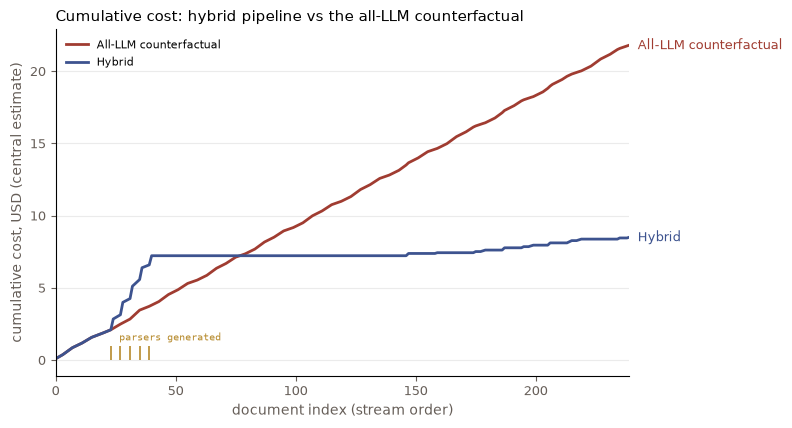

In [12]:
fig, ax = plt.subplots(figsize=(8.5, 4.5))

ax.plot(docs_df["idx"], docs_df["cum_cf_usd_est"], color=COLOR_COUNTERFACTUAL, linewidth=2, solid_capstyle="round")
ax.plot(docs_df["idx"], docs_df["cum_hybrid_usd_est"], color=COLOR_HYBRID, linewidth=2, solid_capstyle="round")

# Mark parser-activation events as thin ticks near the axis, annotated once.
activation_events = evaluation["activation_events"]
activation_xs = [event["after_idx"] for event in activation_events]
y_max = max(docs_df["cum_cf_usd_est"].max(), docs_df["cum_hybrid_usd_est"].max())
tick_height = y_max * 0.045
ax.vlines(activation_xs, ymin=0, ymax=tick_height, color=COLOR_ACTIVATION, linewidth=1.2, zorder=3)
ax.annotate(
    "parsers generated",
    xy=(activation_xs[0], tick_height),
    xytext=(6, 4),
    textcoords="offset points",
    fontsize=7.5,
    family="monospace",
    color=COLOR_ACTIVATION,
)

# Direct end labels for the two series.
last_idx = int(docs_df["idx"].max())
last_cf = docs_df["cum_cf_usd_est"].iloc[-1]
last_hybrid = docs_df["cum_hybrid_usd_est"].iloc[-1]
ax.annotate(
    "All-LLM counterfactual", xy=(last_idx, last_cf), xytext=(6, 0), textcoords="offset points",
    va="center", fontsize=9, color=COLOR_COUNTERFACTUAL, clip_on=False,
)
ax.annotate(
    "Hybrid", xy=(last_idx, last_hybrid), xytext=(6, 0), textcoords="offset points",
    va="center", fontsize=9, color=COLOR_HYBRID, clip_on=False,
)

# Restrained house style.
ax.set_xlabel("document index (stream order)", color=COLOR_MUTED_TICK)
ax.set_ylabel("cumulative cost, USD (central estimate)", color=COLOR_MUTED_TICK)
ax.set_title("Cumulative cost: hybrid pipeline vs the all-LLM counterfactual", fontsize=11, loc="left")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.yaxis.grid(True, alpha=0.25)
ax.xaxis.grid(False)
ax.set_axisbelow(True)
ax.tick_params(colors=COLOR_MUTED_TICK, labelsize=9)
ax.set_xlim(0, last_idx)
ax.legend(
    handles=[
        plt.Line2D([0], [0], color=COLOR_COUNTERFACTUAL, linewidth=2, label="All-LLM counterfactual"),
        plt.Line2D([0], [0], color=COLOR_HYBRID, linewidth=2, label="Hybrid"),
    ],
    loc="upper left", frameon=False, fontsize=8,
)
fig.subplots_adjust(right=0.80)
plt.show()

Caption computed below from `evaluation.json`'s `summary.cost_estimates`.

In [13]:
cost_estimates = evaluation["summary"]["cost_estimates"]
saving_share = cost_estimates["saving_share_of_cf"]
saving_usd = cost_estimates["saving_central_usd_est"]

display(Markdown(
    f"**Estimated saving: ~{saving_share:.0%} of the all-LLM counterfactual** "
    f"(~\\${saving_usd:.2f}, central estimate) over this {len(docs_df)}-document stream. "
    "The saving share grows with stream length — the marginal deterministic "
    "document costs nothing — so this is a within-stream figure, not a ceiling."
))

**Estimated saving: ~61% of the all-LLM counterfactual** (~\$13.30, central estimate) over this 240-document stream. The saving share grows with stream length — the marginal deterministic document costs nothing — so this is a within-stream figure, not a ceiling.

## Stream timeline

Every document plotted by its position in the stream (x) and transaction
type (y), coloured by which path handled it: navy for deterministic, wine
for LLM discovery, gold for LLM fallback. The pattern the design predicted:
LLM markers cluster early (discovery) and reappear briefly late (fallback,
months 8-12), navy filling in between. The single S-class document — parsed
deterministically, silently wrong — is outlined and annotated; nothing else
on this chart marks it out.

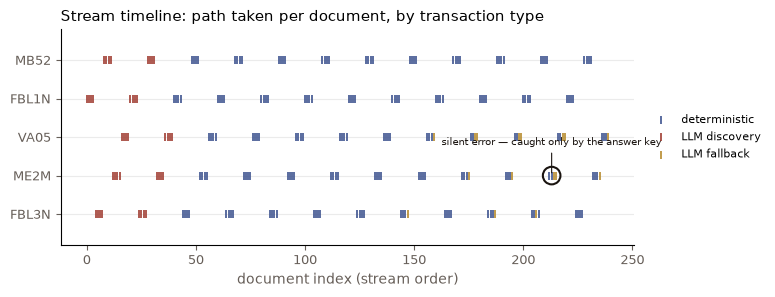

In [14]:
# Type order follows design.md §3's transaction-type taxonomy table.
type_order = ["FBL3N", "ME2M", "VA05", "FBL1N", "MB52"]
type_to_y = {t: i for i, t in enumerate(type_order)}

fig, ax = plt.subplots(figsize=(8.5, 2.8))

path_labels = {
    "deterministic": "deterministic",
    "llm_discovery": "LLM discovery",
    "llm_fallback": "LLM fallback",
}
for path_name, color in PATH_COLORS.items():
    subset = docs_df[docs_df["path"] == path_name]
    ax.scatter(
        subset["idx"], subset["type"].map(type_to_y),
        marker="|", s=40, linewidths=1.2, color=color, label=path_labels[path_name],
    )

# Outline the single S-class document.
s_doc = docs_df[docs_df["class"] == "S"].iloc[0]
ax.scatter(
    [s_doc["idx"]], [type_to_y[s_doc["type"]]],
    marker="o", s=160, facecolors="none", edgecolors=COLOR_SILENT_ERROR, linewidths=1.5, zorder=5,
)
ax.annotate(
    "silent error — caught only by the answer key",
    xy=(s_doc["idx"], type_to_y[s_doc["type"]]),
    xytext=(0, 22), textcoords="offset points",
    fontsize=7.5, color=COLOR_SILENT_ERROR, ha="center",
    arrowprops=dict(arrowstyle="-", color=COLOR_SILENT_ERROR, linewidth=0.8),
)

ax.set_yticks(range(len(type_order)))
ax.set_yticklabels(type_order)
ax.set_ylim(-0.8, len(type_order) - 1 + 0.8)
ax.set_xlabel("document index (stream order)", color=COLOR_MUTED_TICK)
ax.set_title("Stream timeline: path taken per document, by transaction type", fontsize=11, loc="left")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.yaxis.grid(True, alpha=0.25)
ax.xaxis.grid(False)
ax.set_axisbelow(True)
ax.tick_params(colors=COLOR_MUTED_TICK, labelsize=9)
ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=False, fontsize=8)
fig.subplots_adjust(right=0.80)
plt.show()

## Local parse latency

Deterministic parses run locally: no LLM call, no network wait. Median,
p90, and max wall time in milliseconds, from `docs[].parse_ms_local`,
deterministic-path documents only. Table only — the numbers are small and
tight enough that a chart would add nothing.

In [15]:
deterministic_latency_ms = docs_df.loc[docs_df["path"] == "deterministic", "parse_ms_local"]

latency_table = pd.Series({
    "median_ms": deterministic_latency_ms.median(),
    "p90_ms": deterministic_latency_ms.quantile(0.9),
    "max_ms": deterministic_latency_ms.max(),
}).round(3).to_frame(name="milliseconds")
latency_table

,milliseconds
median_ms,2.285
p90_ms,8.138
max_ms,25.470


## Costs, with bands

Method B prices subagent token totals at published per-token rates, as a
band from an all-input floor to an all-output ceiling, with a central
estimate at an 85/15 input/output split (`report.md`, "Cost accounting
method"). The hybrid total includes the one-time cost of generating the
five deterministic parsers; that one-time cost is broken out separately
below, computed from `parse_agent_log.json`'s `overseer_generation_wave`.
All figures on this page are **estimates**.

In [16]:
cost_bands_df = pd.DataFrame(
    {
        "Hybrid pipeline (estimate)": [
            cost_estimates["hybrid"]["floor_all_input_usd"],
            cost_estimates["hybrid"]["central_85_15_usd"],
            cost_estimates["hybrid"]["ceiling_all_output_usd"],
        ],
        "All-LLM counterfactual (estimate)": [
            cost_estimates["counterfactual_all_llm"]["floor_all_input_usd"],
            cost_estimates["counterfactual_all_llm"]["central_85_15_usd"],
            cost_estimates["counterfactual_all_llm"]["ceiling_all_output_usd"],
        ],
    },
    index=["floor (all-input rate)", "central (85/15 split)", "ceiling (all-output rate)"],
).T
cost_bands_df

,floor (all-input rate),central (85/15 split),ceiling (all-output rate)
Hybrid pipeline (estimate),5.32,8.51,26.60
All-LLM counterfactual (estimate),13.63,21.81,68.15


In [17]:
overseer_tokens = parse_agent_log["overseer_generation_wave"]["totals"]["subagent_tokens"]
overseer_floor, overseer_central, overseer_ceiling = cost_band_usd(
    overseer_tokens, PRICING["usd_per_mtok_input"], PRICING["usd_per_mtok_output"]
)

overseer_cost_df = pd.DataFrame(
    {
        "tokens_measured": [overseer_tokens],
        "floor_usd_est": [round(overseer_floor, 2)],
        "central_usd_est": [round(overseer_central, 2)],
        "ceiling_usd_est": [round(overseer_ceiling, 2)],
    },
    index=["Overseer parser-generation (one-time, 5 parsers, estimate)"],
)
overseer_cost_df

,tokens_measured,floor_usd_est,central_usd_est,ceiling_usd_est
"Overseer parser-generation (one-time, 5 parsers, estimate)",729630,2.19,3.5,10.94


## What this run says

Three things carry forward to the writeup (`report.md`, "What feeds
forward"):

1. **Pre-registration made the deviations visible.** The FBL1N
   fail-and-recover documents were designed to break the generated parser;
   they didn't — the parser turned out to handle per-currency totals
   correctly, so all five stayed on the deterministic path instead of
   falling back. Because the design's target was frozen before this run,
   that is a checkable deviation in the scorecard above, not a story told
   after the fact.
2. **Deterministic accuracy is a property of code; LLM accuracy is a
   property of the brief.** The fallback wave's 13 field errors all trace to
   one dropped qualifier in a compressed prompt. The lesson is structural,
   not incidental: version your briefs the way you version parsers.
3. **The S-class document is the honest ceiling.** It parses cleanly, passes
   schema, totals, and master-data checks, and is wrong — caught only
   because a synthetic answer key exists to catch it. In production, nothing
   in this pipeline would have. The recommendation that follows is sampled
   human reconciliation plus a line-level price × quantity cross-check,
   which would have caught this one on parsed values.